In [1]:
import scvelo as scv
import scanpy as sc
import pandas as pd 
import numpy as np 
import os 
from pathlib import Path

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\xenium_mouse_gut'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
abs_path = str(Path(notebook_dir).parents[3])
os.chdir(abs_path)
os.getcwd()

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github'

# Adata

In [5]:
adata = scv.read("data/xenium/processed/adata_gut_filtered.h5ad")

In [6]:
adata.X=adata.layers['spliced']+adata.layers['unspliced']
adata.obsm['spatial']=np.array(adata.obs.loc[:,['x_centroid','y_centroid']])

In [7]:
adata

AnnData object with n_obs × n_vars = 98944 × 379
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'total_counts', 'cell_area', 'nucleus_area'
    var: 'gene_name', 'Ensemble ID', 'feature_types', 'genome'
    obsm: 'spatial'
    layers: 'spliced', 'unspliced'

In [8]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')
import sys  
sys.path.insert(1,stvelo_path)
from pipelines.simulation_3ode_class import Simulation3ODE
from pipelines.metrics import *
from pipelines.preprocessing import Preprocessing
from pipelines.compute_velocity import Velocities
from pipelines.utils import proportions_nuc_cyto

<Axes: >

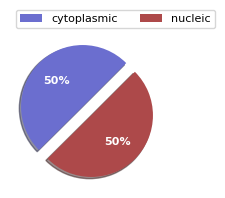

In [9]:
proportions_nuc_cyto(adata)

In [10]:
# Config 

config_preprocessing = {'preprocess_params': {
     'min_counts': 200, 
     'min_cells': 5,
     'n_neighbors': 15,
     'n_pcs': 15,
     'min_dist': 0.8,
     'resolution':0.7},
'functions_to_apply': {'filter_cells': True, 
                       'filter_genes': True, 
                       'normalize_total': True,
                       'log1p': True,
                       'pca': True,
                       'neighbors': True,
                       'umap': True,
                       'leiden': True,
                       'moments': True}}


# config_velocity = { 'velocity_types': ['dynamical','deterministic','stochastic','velovi']}
config_velocity = { 'velocity_types': ['deterministic','dynamical','stochastic','velovi'],
                   'n_jobs':12,
                   'epochs':300}


config_plotting = {
    'colorsets': ['leiden', 'clusters'],
    'velocity_embedding_stream': True,
    'velocity_embedding_grid': True,
    'velocity_embedding': True,
    'rank_velocity_genes': True,
    'velocity_confidence': True,
    'velocity_length': True
}



In [11]:
# took around 3 min 
preprocessor = Preprocessing(adata,config_preprocessing)
adata = preprocessor.preprocess_data()

Normalized count data: spliced, unspliced.
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [12]:
adata.obs['leiden'].value_counts()

leiden
0     8108
1     7379
2     6521
3     5508
4     5327
5     4983
6     4354
7     4098
8     3652
9     3522
10    3504
11     769
12     432
13      33
Name: count, dtype: int64

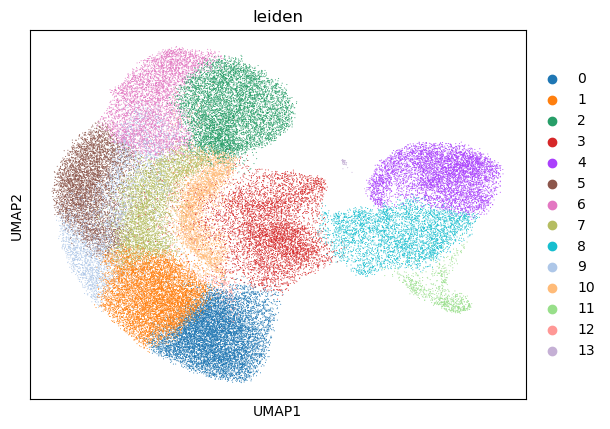

In [13]:
sc.pl.umap(adata,color='leiden')

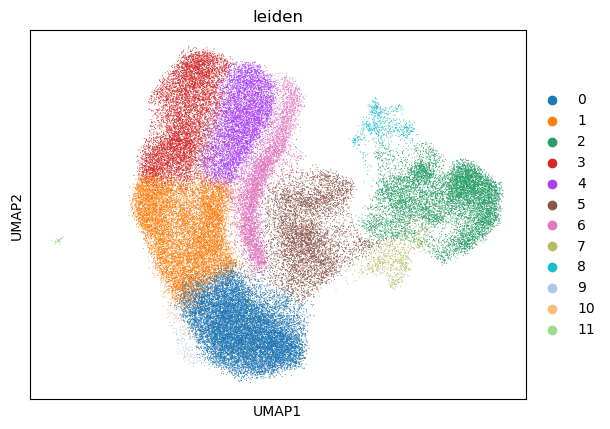

In [15]:
sc.pl.umap(adata,color='leiden')

In [14]:
adata_dict = {"adata_mouse_gut":adata}
velocity_computer = Velocities(adata_dict,config_velocity)
adata_dict_velocity = velocity_computer.compute_velocities()

Using device: cuda
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:01:04) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 12/24 cores)
    finished (0:17:26) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
dynamical velocity is being calculated.
computing velocities
    finished (0:00:10) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:18) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities


c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\tools\optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:22) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
min_max_scaler is working!


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A2000 8GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 300/300: 100%|██████████| 300/300 [23:40<00:00,  7.50s/it, v_num=1, train_loss_step=-1.36e+3, train_loss_epoch=-1.37e+3]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|██████████| 300/300 [23:40<00:00,  4.73s/it, v_num=1, train_loss_step=-1.36e+3, train_loss_epoch=-1.37e+3]


In [17]:
adata_dict = adata_dict_velocity[1]

## Deterministic Velocity

In [22]:
scv.tl.velocity_graph(adata_dict['adata_mouse_gut_velovi'])

computing velocity graph (using 1/24 cores)
    finished (0:01:06) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
c:\Users\OmerCagatayTalikaci\anaconda

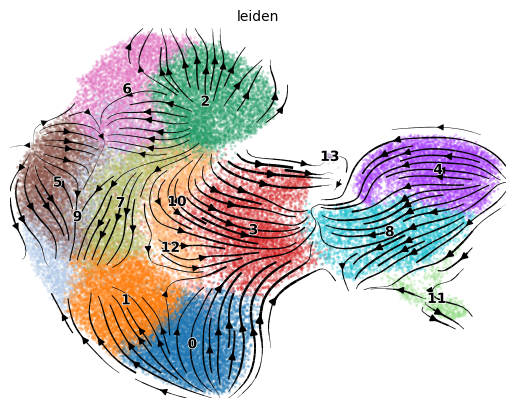

In [24]:
scv.pl.velocity_embedding_stream(adata_dict['adata_mouse_gut_velovi'], basis='umap',color='leiden')

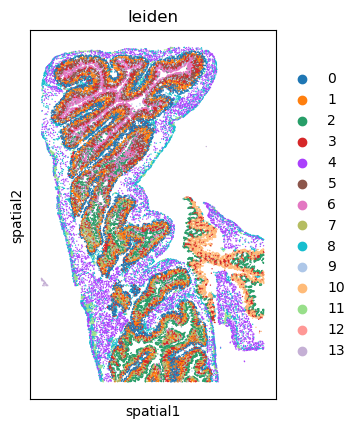

In [19]:
sc.pl.spatial(adata, color="leiden", spot_size = 20)

computing velocity embedding
    finished (0:00:05) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
c:\Users\OmerCagatayTalikaci\anaconda

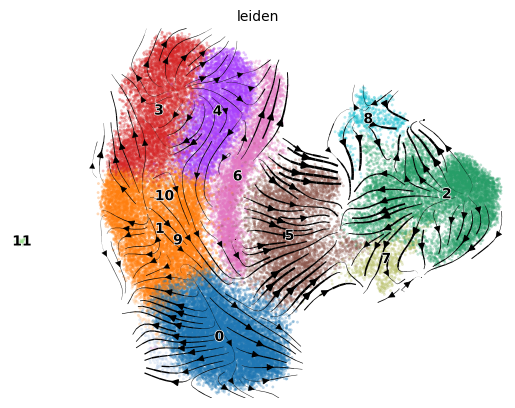

In [25]:
scv.pl.velocity_embedding_stream(adata_dict_velocity['adata_mouse_gut_stochastic'], basis='umap',color='leiden')

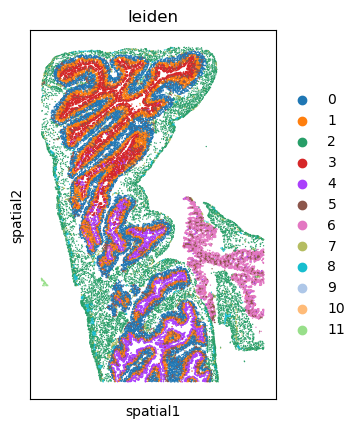

In [19]:
sc.pl.spatial(adata, color="leiden", spot_size = 20)

In [28]:
transition_matrix = scv.utils.get_transition_matrix(adata)

In [29]:
transition_matrix

<3696x3696 sparse matrix of type '<class 'numpy.float32'>'
	with 681987 stored elements in Compressed Sparse Row format>

## Dynamic Velocity 

In [36]:
adata = scv.read("data/Xenium_V1_mouse_pup_outs/adata_filtered.h5ad")

In [37]:
# filter, normalize 
sc.pp.filter_cells(adata,min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [38]:

# pca, neighbours, umap, leiden
sc.pp.pca(adata)
sc.pp.neighbors(adata,n_neighbors=30,n_pcs=30)
sc.tl.umap(adata,min_dist=0.05)
sc.tl.leiden(adata)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [39]:
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

Normalized count data: spliced, unspliced.
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [40]:
scv.tl.recover_dynamics(adata)

recovering dynamics (using 1/8 cores)
    finished (0:30:33) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [41]:
scv.tl.velocity(adata, mode='dynamical')

computing velocities
    finished (0:00:08) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [42]:
scv.tl.velocity_graph(adata)

computing velocity graph (using 1/8 cores)
    finished (0:00:23) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:6

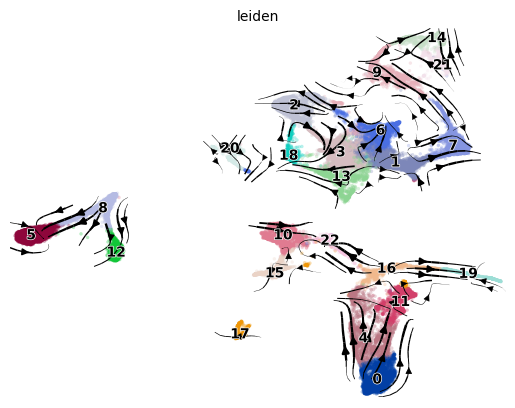

In [44]:
scv.pl.velocity_embedding_stream(adata, basis='umap',color="leiden")

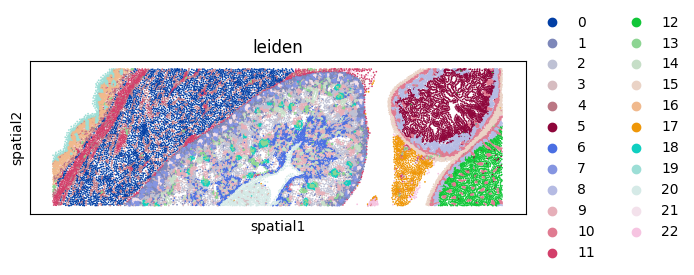

In [45]:
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()
sc.pl.spatial(adata, color="leiden", spot_size = 15)

In [46]:
adata.write("data/Xenium_V1_mouse_pup_outs/adata_filtered_dynamic.h5ad")

In [47]:
adata

AnnData object with n_obs × n_vars = 39291 × 379
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'leiden', 'velocity_self_transition'
    var: 'gene_name', 'Ensemble ID', 'feature_types', 'genome', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg', 'leiden_colors'
    obsm: 'X_pca', 'X_umap', 'velocity_umap', 'spatial'
    varm: 'PCs', 'loss'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'velocity', 'velocity_u'
    obsp: 'distances', 'connectivities'

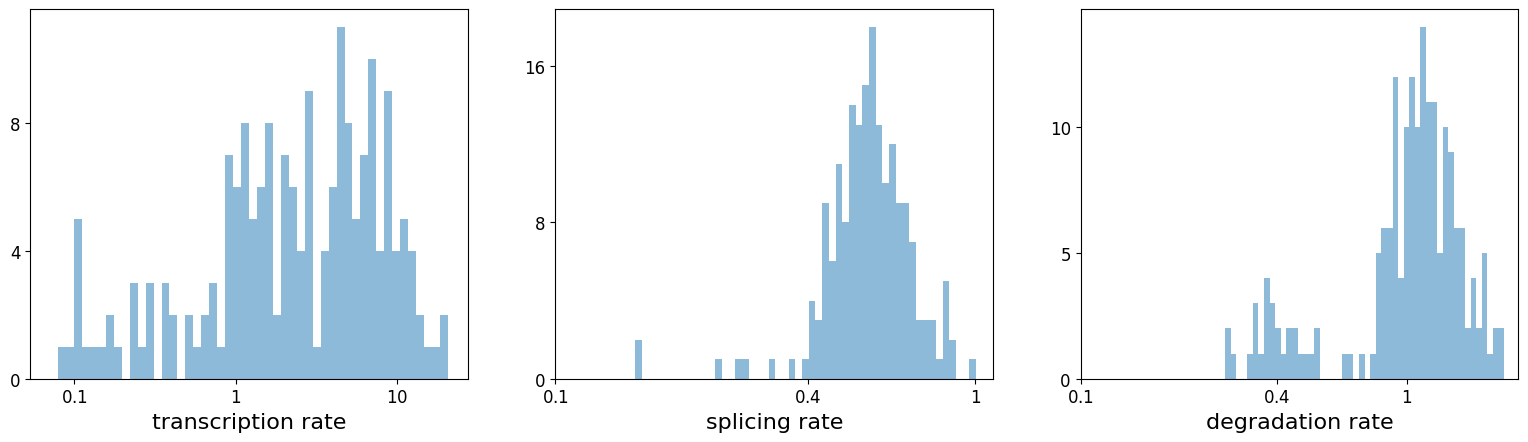

/var/folders/n1/3rys77050fl0ptsh50jc4t_40000gn/T/ipykernel_2343/3074921153.py:9: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  scv.get_df(adata, 'fit*', dropna=True).head()


,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling
0,0.575385,0.112396,0.322276,0.395703,7.789025,1.814174,0.119005,0.077678,1.794359e-01,0.0,0.0,0.392269,0.359788,0.221242,1.315029,1.928931
2,0.715265,0.405616,1.265251,0.720712,3.773082,0.350789,0.098499,0.132675,3.104221e-01,0.0,0.0,0.292923,0.230714,0.272459,0.382785,1.032897
3,0.526545,0.474908,0.454523,0.391046,3.318019,2.702283,0.224934,0.141922,2.506094e-32,0.0,0.0,0.481683,1.023229,0.551857,1.185364,1.276205
4,0.644970,0.296406,0.762489,0.499205,7.405457,1.003752,0.129365,0.173668,2.252490e-01,0.0,0.0,0.412565,0.353487,0.516870,0.902432,1.592952
6,0.692437,0.192532,0.352494,0.427203,6.027383,1.926021,0.172434,0.126907,2.075628e-01,0.0,0.0,0.392151,0.475293,0.361893,0.856140,1.988480


In [48]:
df = adata.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]
kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

scv.get_df(adata, 'fit*', dropna=True).head()

In [55]:
adata.var.iloc[[0,2,3,4,6]].gene_name

0    0610005C13Rik
2    2610528A11Rik
3    5330417C22Rik
4    6330403K07Rik
6         AU021092
Name: gene_name, dtype: object

### latent time 

computing terminal states
    identified 3 regions of root cells and 7 regions of end points .
    finished (0:00:05) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:07) --> added 
    'latent_time', shared time (adata.obs)


/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:6

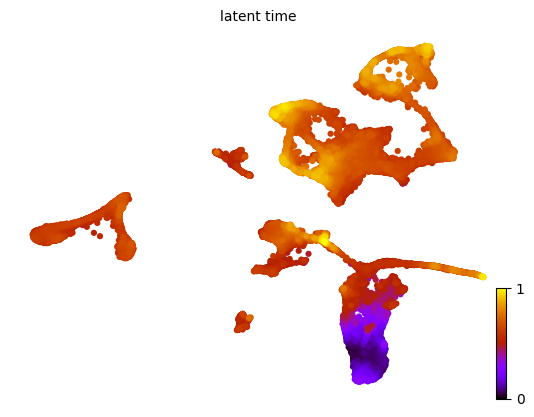

In [57]:
scv.tl.latent_time(adata)
scv.pl.scatter(adata, color='latent_time', color_map='gnuplot', size=80)

In [64]:
adata.var.set_index("gene_name",drop=True,inplace=True)

In [25]:
top_genes = adata_dict['adata_mouse_gut_dynamical'].var['fit_likelihood'].sort_values(ascending=False).index
scv.pl.heatmap(adata, var_names=top_genes, sortby='latent_time',  n_convolve=100)

KeyError: 'latent_time'

c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\plotting\utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
c:\Users\OmerCagatayTalikaci\anaconda

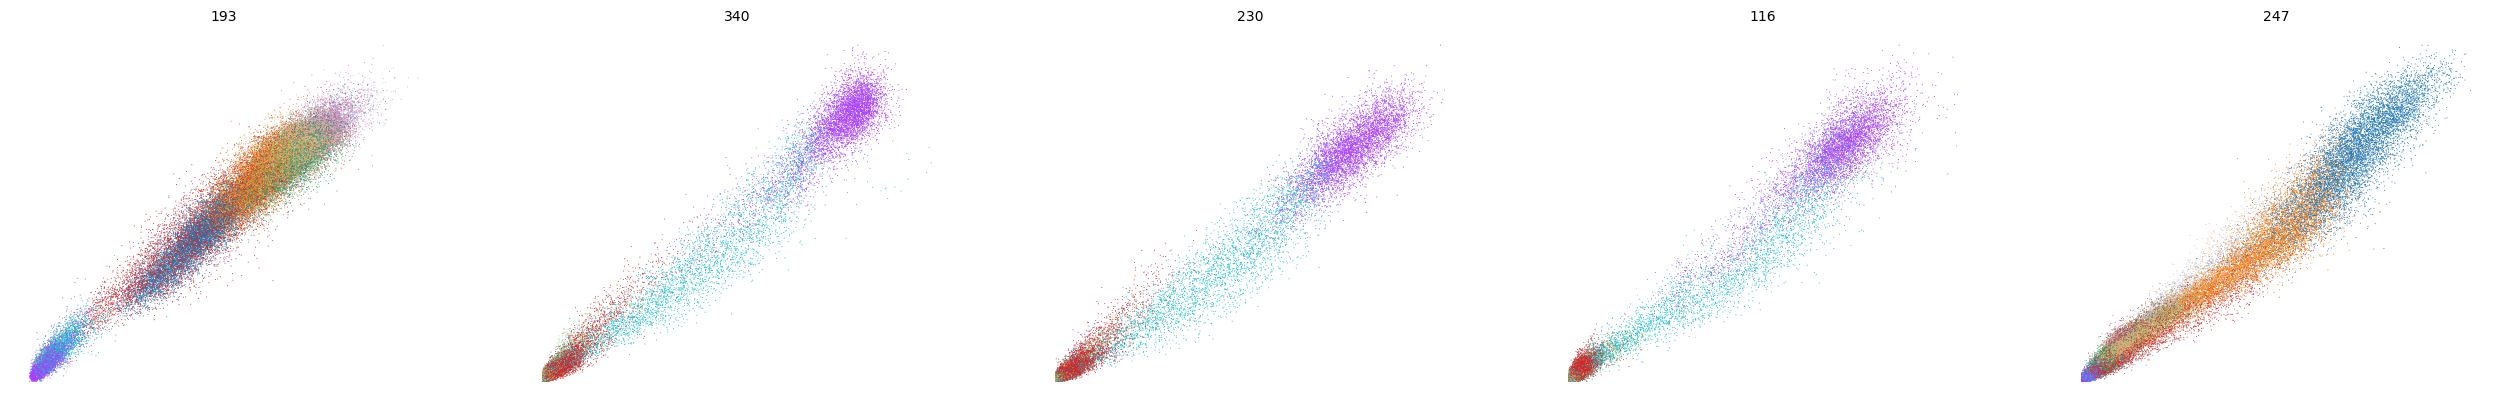

In [28]:
top_genes = adata_dict['adata_mouse_gut_dynamical'].var['fit_likelihood'].sort_values(ascending=False).index
scv.pl.scatter(adata, basis=top_genes[:5],color='leiden' ,ncols=5, frameon=False)

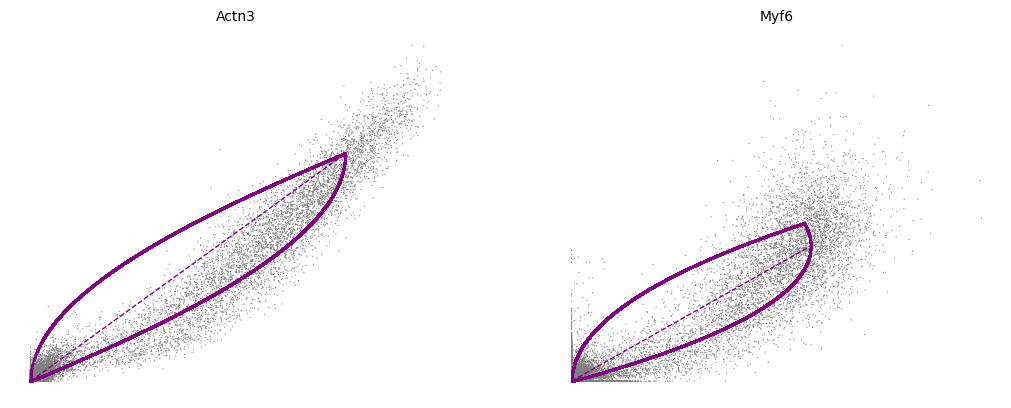

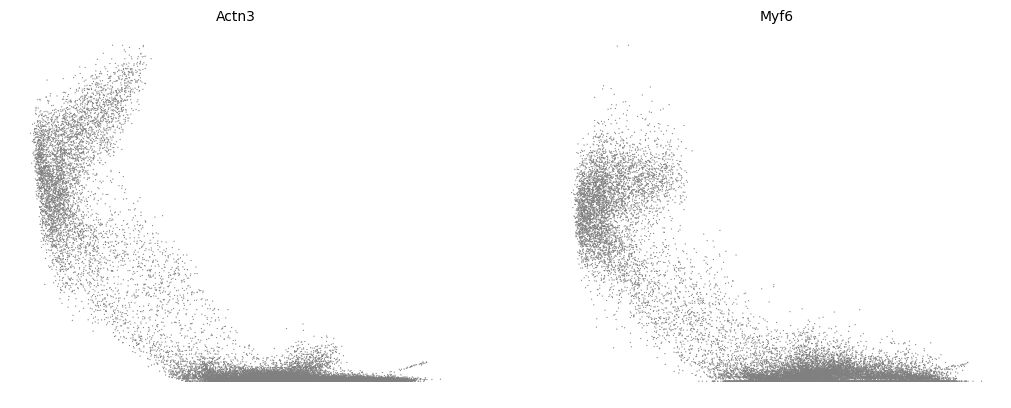

In [71]:
var_names = ['Actn3', 'Myf6']
scv.pl.scatter(adata, var_names, frameon=False)
scv.pl.scatter(adata, x='latent_time', y=var_names, frameon=False)

## Stochastic Velocity 

In [74]:
adata = scv.read("data/Xenium_V1_mouse_pup_outs/adata_filtered.h5ad")

In [75]:
# filter, normalize 
sc.pp.filter_cells(adata,min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
# pca, neighbours, umap, leiden
sc.pp.pca(adata)
sc.pp.neighbors(adata,n_neighbors=30,n_pcs=30)
sc.tl.umap(adata,min_dist=0.05)
sc.tl.leiden(adata)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [76]:
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)
scv.tl.velocity(adata, mode='stochastic')

Normalized count data: spliced, unspliced.
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:03) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [77]:
scv.tl.velocity_graph(adata)

computing velocity graph (using 1/8 cores)
    finished (0:00:59) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/plotting/utils.py:6

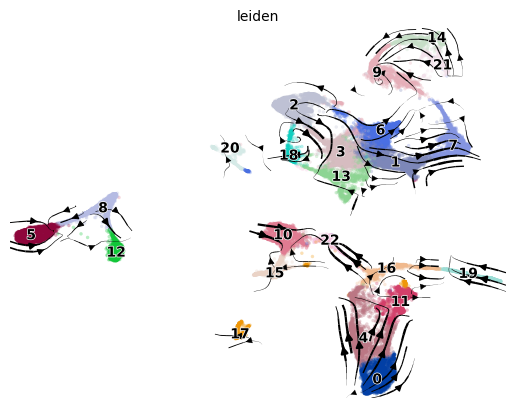

In [80]:
scv.pl.velocity_embedding_stream(adata, basis='umap', color="leiden")